In [1]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.methods import RVPermutationTest
from src.helper_functions.simulation_functions import run_simulation
from src.helper_functions.analyse_functions import aggregate_results
import re
from src.helper_functions.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np
from functools import partial

In [2]:
import matplotlib.pyplot as plt


rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "figure.titlesize": 11,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10.5,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
}

plt.rcParams.update(rcparams)

In [3]:
colors = {
    'PermutationTest_cvm_stat_multivariate': '#1f77b4',
    'RVPermutationTest': '#9467bd',
    'DiffusionCorrelation':'#ff7f0e',
    'ObservedCVM':'#2ca02c',
    'QAP':'#d62728',
    'PermutationTest_cvm_stat_block_independence':'#17BECF',
    'LLKRatioTest':'#8C564B',
}

linestyles = {
    'PermutationTest_cvm_stat_multivariate': '-',
    'RVPermutationTest': (0, (8, 4)),
    'DiffusionCorrelation': (0, (5, 3)),
    'ObservedCVM': (0, (2, 2)),
    'QAP': (0, (6, 3, 1.5, 3)),
    'PermutationTest_cvm_stat_block_independence': (0, (8, 3, 1.5, 3, 1.5, 3)),
    'LLKRatioTest': (0, (1, 2)),
}
plotting_function = partial(plot_with_bands, colors=colors, linestyles=linestyles)

In [4]:
# results1 = pd.read_csv("simulation_results_20260317_1136.csv")

In [5]:
# results2 = pd.read_csv("simulation_results_20260318_1638.csv")

In [6]:
results3 = pd.read_csv("simulation_results_20260320_1246.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'simulation_results_20260320_1246.csv'

In [ ]:
#results1 = pd.read_csv("simulation_results_20260311_1610.csv")

In [ ]:
# null hp
# results2 = pd.read_csv("simulation_results_20260312_0828.csv")

In [ ]:
# block independence
# results3 = pd.read_csv("simulation_results_20260312_2242.csv")

In [ ]:
# QAP
# results7 = pd.read_csv("simulation_results_20260313_1059.csv")

In [ ]:
# results8 = pd.read_csv("simulation_results_20260313_1538.csv")

In [ ]:
# results9 = pd.read_csv("simulation_results_20260316_1217.csv")

In [ ]:
results_concat = pd.concat([results3], ignore_index=True)

In [ ]:
import re

def parse_config_string(s):
    # extract rough key-value pairs
    pairs = dict(re.findall(r"'([^']+)':\s*([^,}]+)", s))

    # extract method class specifically from the 'method' field (not globally)
    method_val_match = re.search(r"'method':\s*(.*?)(?=,\s*'[^']+':|$|})", s, re.DOTALL)
    method_class, test_function = None, None

    if method_val_match:
        method_val = method_val_match.group(1)
        cm = re.search(r"<class '([^']+)'>", method_val)
        if cm:
            method_class = cm.group(1).split('.')[-1]
        fm = re.search(r"test_function=<function ([^ ]+)", method_val)
        if fm:
            test_function = fm.group(1)

    if method_class == "PermutationTest" and test_function:
        method = f"{method_class}_{test_function}"
    else:
        method = method_class
    pairs["method"] = method

    # extract solver: handle both plain string and <function Name at 0x...>
    solver_match = re.search(r"'solver':\s*<function ([^ ]+)", s)
    if solver_match:
        pairs["solver"] = solver_match.group(1)

    # clean up np.int64/np.float64 wrappers
    for k, v in pairs.items():
        nm = re.match(r"np\.\w+\(([^)]+)\)", str(v).strip())
        if nm:
            pairs[k] = nm.group(1)
    
    #extract degree 
    pairs['degree'] = re.search(r"degree=(\d+)", s).group(1) if re.search(r"degree=(\d+)", s) else "NA"

    return pairs

In [ ]:
def parse_result_string(s):
    # remove numpy scalar wrappers
    s_clean = re.sub(r"np\.float64\((.*?)\)", r"\1", s)

    return ast.literal_eval(s_clean)

In [ ]:
results = results_concat.copy()
results['args'] = results['args'].apply(parse_config_string)

In [ ]:
results['ComputeAll'] = results['ComputeAll'].apply(parse_result_string)

In [ ]:
results["edge_var"] = results["args"].apply(lambda x: x.get("edge_var", "NA"))
results['n'] = results['args'].apply(lambda x: x.get("n", "NA"))
results['k'] = results['args'].apply(lambda x: x.get("k", "NA"))
results['method'] = results['args'].apply(lambda x: x.get("method", "NA").strip("'"))
results['solver'] = results['args'].apply(lambda x: x.get("solver", "NA").strip("'"))
results['copula'] = results['args'].apply(lambda x: x.get("copula_type", "NA").strip("'"))
results['dgp_name'] = results['args'].apply(lambda x: x.get("dgp_name", "NA").strip("'"))
results['marginals'] = results['args'].apply(lambda x: x.get("marginals", "NA").strip("'"))
results['rho'] = results['args'].apply(lambda x: x.get("rho", "NA").replace('np.float64(', '').replace(')', ''))
results['rho'] = results['rho'].apply(lambda x: float(x))
results['degree'] = results['args'].apply(lambda x: x.get("degree", "NA").replace('np.int64(', '').replace(')', ''))

In [ ]:
results['n'] = results['n'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))
results['k'] = results['k'].apply(lambda x: int(x.replace('np.int64(', '').replace(')', '')))

In [ ]:
results["dgp"] = results["args"].apply(lambda x: x.get("dgp_name", "NA"))
results['dgp_name'] =  [x.split('_')[0].strip("'") for x in results['dgp']]
results['copula'] =  [x.split('_')[1].strip("'") for x in results['dgp']]

In [ ]:
results_all = results.copy()

In [ ]:
results_all["RelativeFrobeniusNorm_x"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_x", np.nan)
)
results_all["RelativeFrobeniusNorm_z"] = results_all["ComputeAll"].apply(
    lambda x: x.get("RelativeFrobeniusNorm_z", np.nan)
)
results_all["FalseRejection"] = results_all["ComputeAll"].apply(lambda x: x["FalseRejection"])
results_all["TrueRejection"] = results_all["ComputeAll"].apply(lambda x: x["TrueRejection"])
results_all["Rejection"] = results_all["ComputeAll"].apply(lambda x: x["Rejection"])

In [ ]:
results_all['avg_rel_frob_x'] = (
    results_all
    .groupby(['n', 'method', 'marginals', 'copula', 'dgp_name'])['RelativeFrobeniusNorm_x']
    .transform('mean')
)

In [ ]:
results_all = results_all[~results_all['method'].isin(['PermutationTest_cvm_stat_multivariate','PermutationTest_cvm_stat_block_independence'])].copy()

In [ ]:
results_all.rename(columns={'TrueRejection': 'Power'}, inplace=True)

In [ ]:
results_all = results_all[results_all['edge_var']=='1']

In [ ]:
results_all['degree'] = results_all['degree'].replace('NA', 'QAP')

### Defining different aggregations

In [ ]:
# based on dgp
results_gaussian = results_all[(results_all["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results_all[(results_all["dgp_name"] == "BernoulliNetwork")].copy()

In [ ]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == 0.0)].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == 0.5)].copy()
results_alt_02_gaussian = results_gaussian[(results_gaussian["rho"] == 0.2)].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.0)].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.5)].copy()
results_alt_02_bernoulli = results_bernoulli[(results_bernoulli["rho"] == 0.2)].copy()

## Type I error

**Ensure type I error is controlled at 5%**

In [ ]:
agg_null_gaussian = aggregate_results(results_null_gaussian,
                                      y_axis="FalseRejection",
                                      x_axis="n",
                                      factors=["marginals", "degree", "copula"])

agg_null_bernoulli = aggregate_results(results_null_bernoulli, 
                             y_axis="FalseRejection",
                             x_axis="n",
                             factors=["marginals", "degree", "copula"])

agg_null_gaussian_frob = aggregate_results(results_null_gaussian,
                                           y_axis="FalseRejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["marginals", "degree", "copula"])
agg_null_bernoulli_frob = aggregate_results(results_null_bernoulli,
                                           y_axis="FalseRejection",
                                           x_axis="avg_rel_frob_x",
                                           factors=["marginals", "degree", "copula"])

In [ ]:
rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 17,
    "figure.titlesize": 17,
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
}

plt.rcParams.update(rcparams)

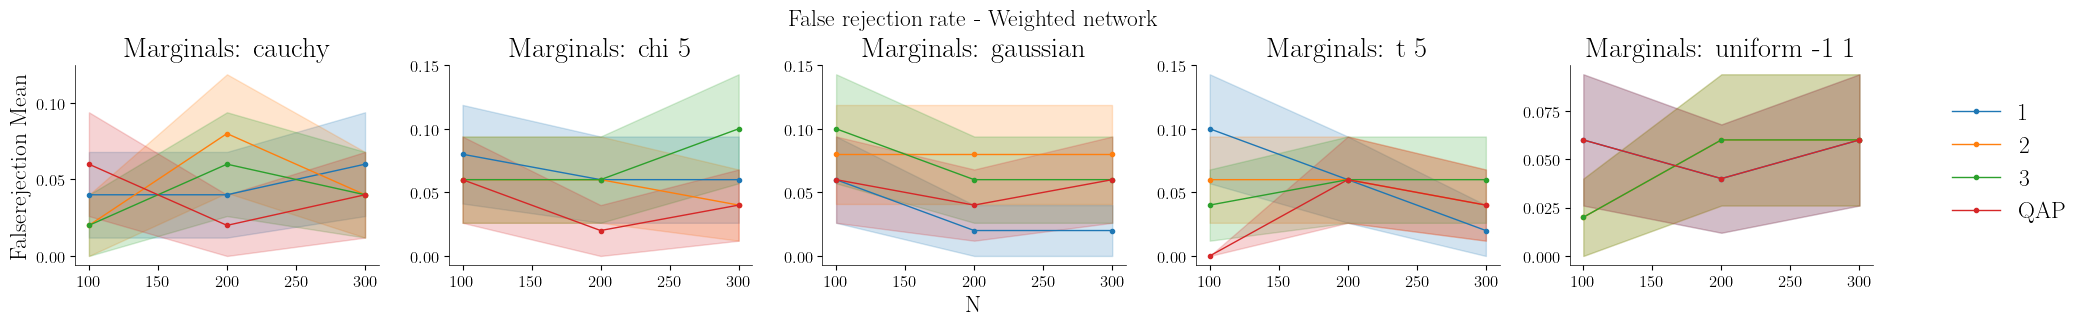

In [ ]:
temp = agg_null_gaussian.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["degree", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="False rejection rate - Weighted network",
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=False,
#     title="False rejection rate - Weighted network",
#     save_path='figures/false_rejection_rate_weighted_network'
# )

# plot_grid(
#     grouped_stats=temp[temp['method']!="ObservedCVM"],
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=False,
#     title="False rejection rate - Weighted network",
#     save_path='figures/false_rejection_rate_weighted_network_nocvm'
# )

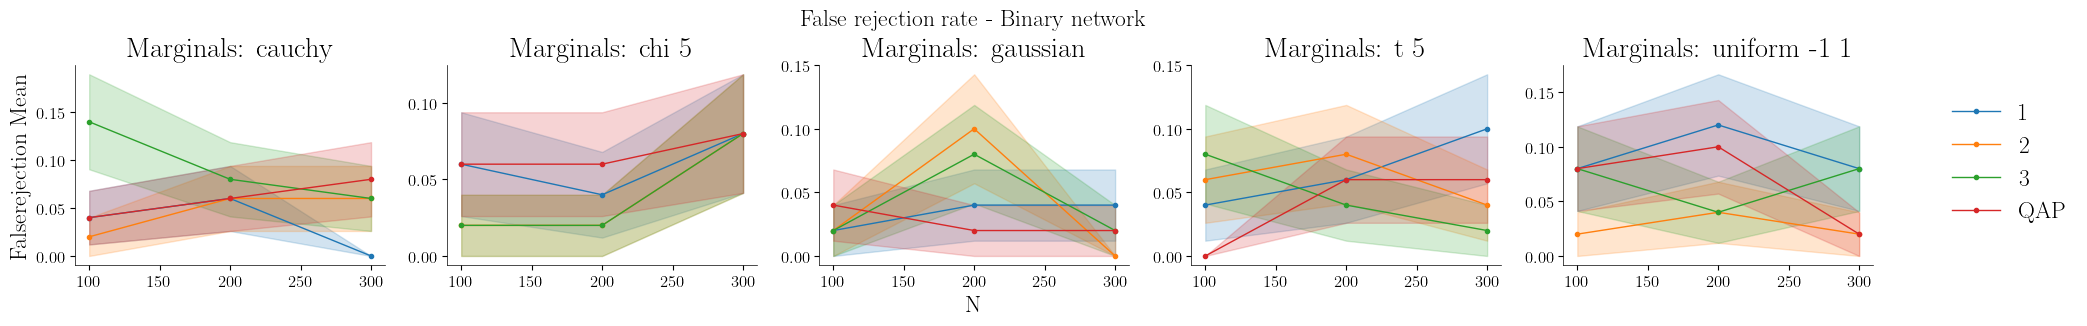

In [ ]:
temp = agg_null_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="FalseRejection_mean",
    factors=["degree", "marginals",],
    height=3,
    se_bands="FalseRejection_sem",
    share_x=True,
    share_y=False,
    title="False rejection rate - Binary network",
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=False,
#     title="False rejection rate - Binary network",
#     save_path='figures/false_rejection_rate_binary_network'
# )


# plot_grid(
#     grouped_stats=temp[temp['method']!="ObservedCVM"],
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="FalseRejection_mean",
#     factors=["method", "marginals",],
#     height=3,
#     se_bands="FalseRejection_sem",
#     share_x=True,
#     share_y=False,
#     title="False rejection rate - Binary network",
#     save_path='figures/false_rejection_rate_binary_network_nocvm'
# )


### Power

In [ ]:
agg_alt_02_gaussian = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "degree", "copula"]
)
agg_alt_02_bernoulli = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="n",
    factors=["marginals", "degree", "copula"]
)

agg_alt_02_gaussian_frob = aggregate_results(
    results_alt_02_gaussian,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "degree", "copula"]
)

agg_alt_02_bernoulli_frob = aggregate_results(
    results_alt_02_bernoulli,
    y_axis="Power",
    x_axis="avg_rel_frob_x",
    factors=["marginals", "degree", "copula"]
)

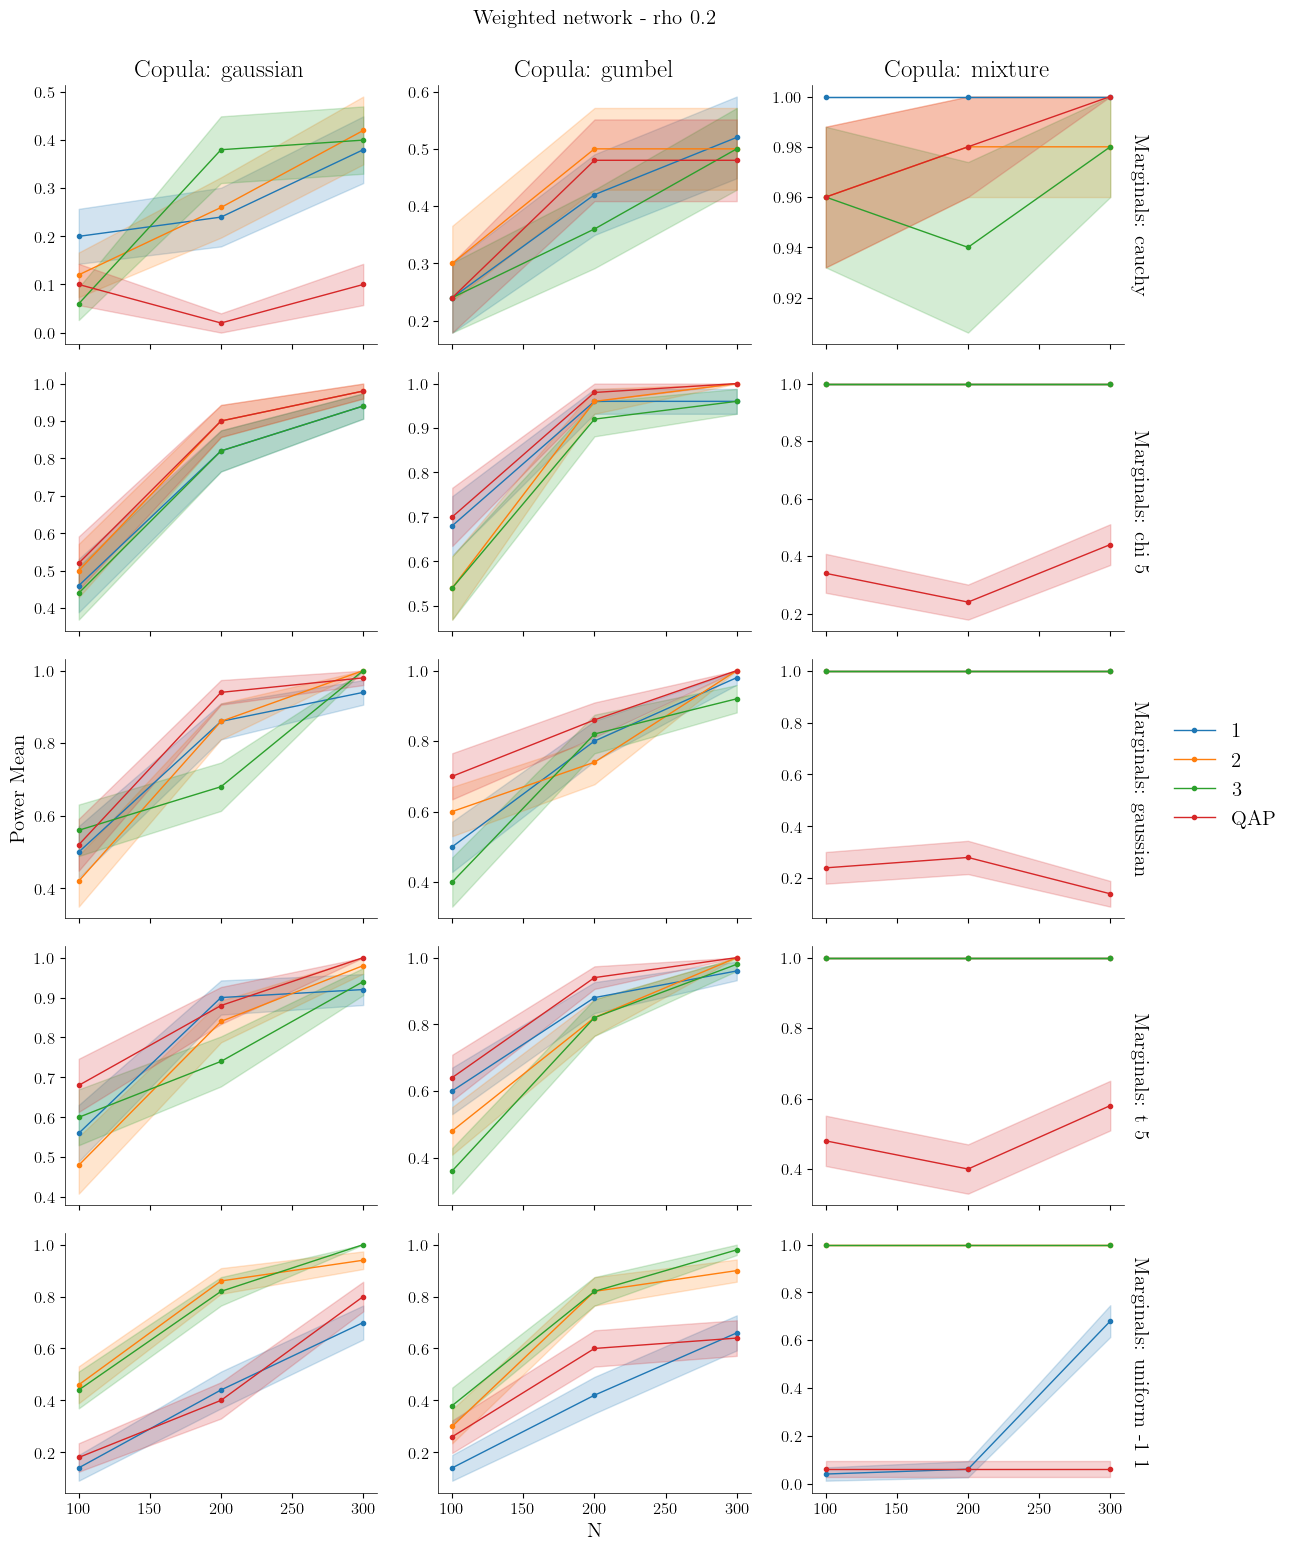

In [ ]:
temp = agg_alt_02_gaussian.copy()

rcparams = {
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 15,
    "figure.titlesize": 15,
    "legend.fontsize": 15,
    "legend.title_fontsize": 15,
    "lines.linewidth": 1,
    "axes.linewidth": 0.5,
    "axes.facecolor": "white",
    "axes.grid": False,
    "lines.markersize": 3,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
}

plt.rcParams.update(rcparams)


plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["degree", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Weighted network - rho 0.2",
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Weighted network - rho 0.2",
#     save_path="figures/power_weighted_02"
# )

# plot_grid(
#     grouped_stats=temp[temp['method']!="ObservedCVM"],
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Weighted network - rho 0.2",
#     save_path="figures/power_weighted_02_nocvm"
# )

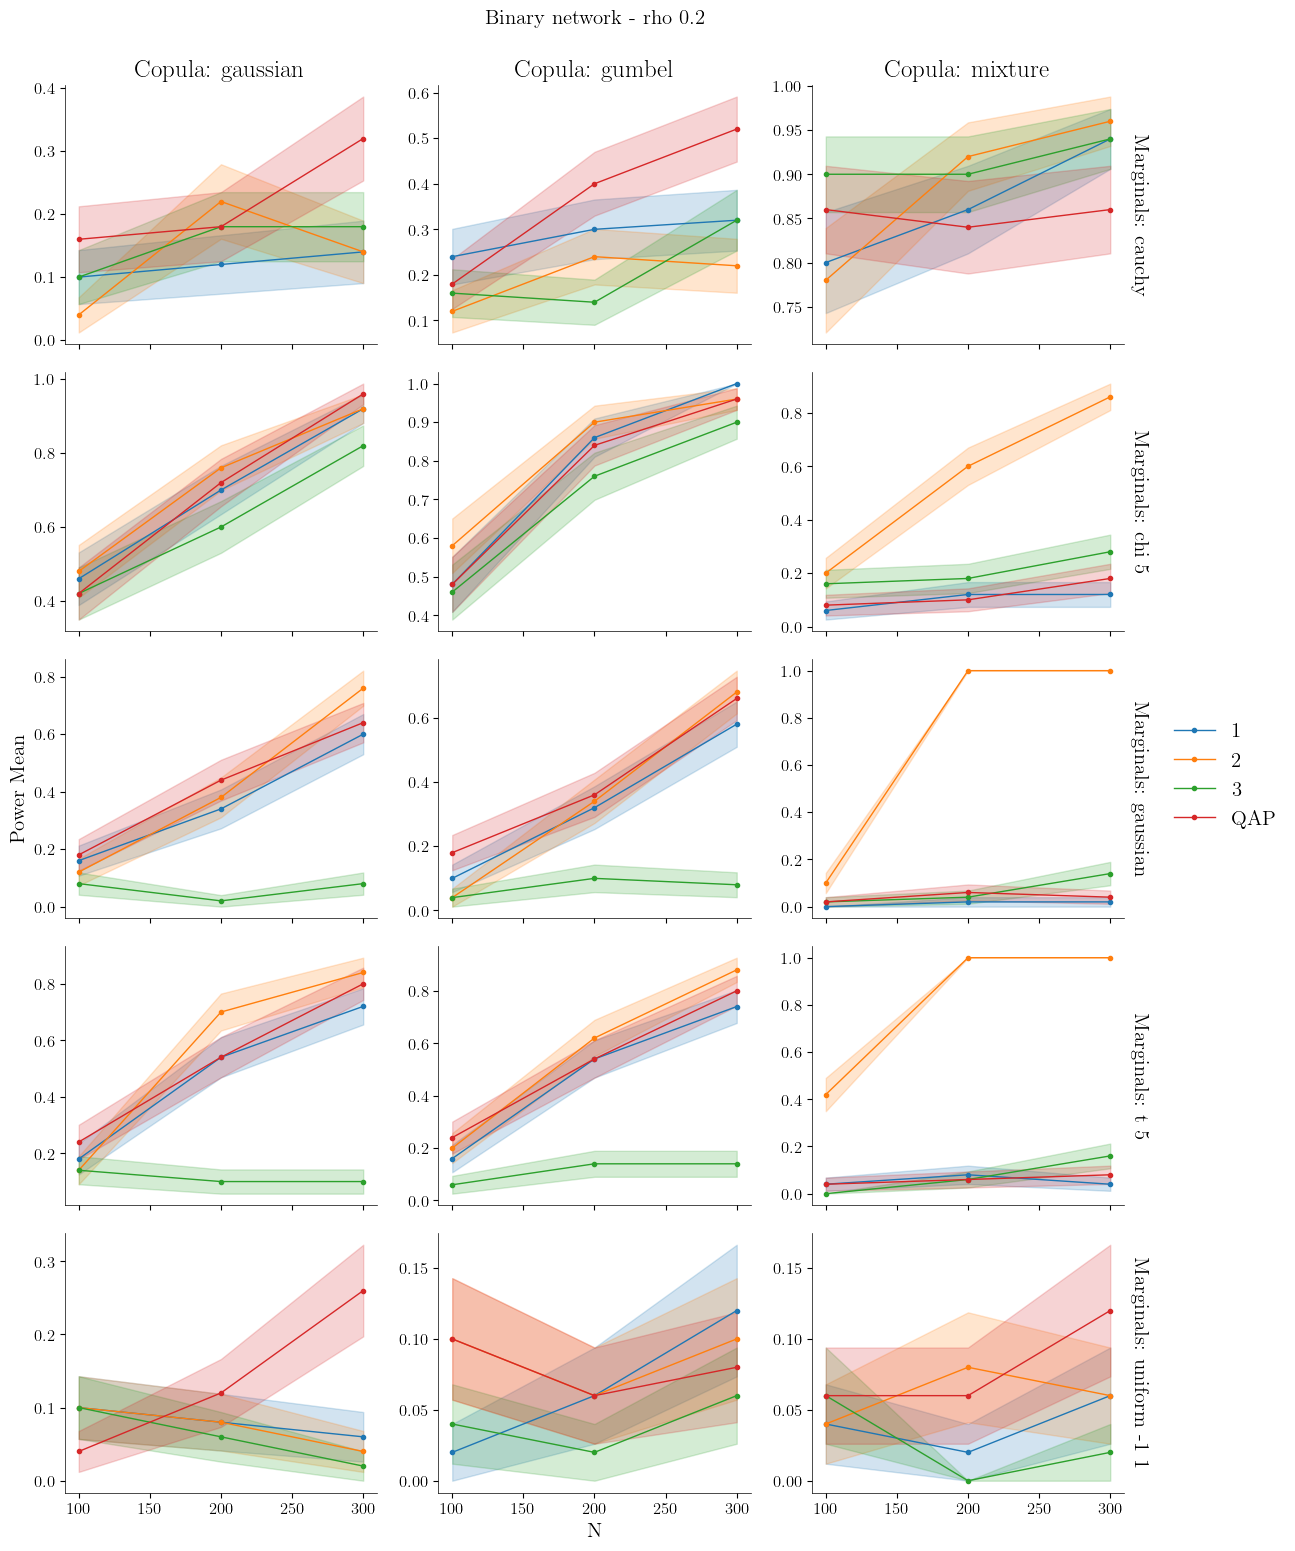

In [ ]:
temp = agg_alt_02_bernoulli.copy()

plot_grid(
    grouped_stats=temp,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="Power_mean",
    factors=["degree", "copula", "marginals"],
    height=3,
    se_bands="Power_sem",
    share_x=True,
    share_y=False,
    title="Binary network - rho 0.2",
)

# plot_grid(
#     grouped_stats=temp,
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Binary network - rho 0.2",
#     save_path="figures/power_binary_02"
# )

# plot_grid(
#     grouped_stats=temp[temp['method']!="ObservedCVM"],
#     plotting_function=plotting_function,
#     x_axis="n",
#     y_axis="Power_mean",
#     factors=["method", "copula", "marginals"],
#     height=3,
#     se_bands="Power_sem",
#     share_x=True,
#     share_y=False,
#     title="Binary network - rho 0.2",
#     save_path="figures/power_binary_02_nocvm"
# )